In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Literal

In [4]:
# Create State
class quadState(TypedDict):
    a:int
    b:int
    c:int
    equation: str
    discriminant: float
    result: str

In [5]:
def show_equation(state: quadState):
    a = state['a']
    b = state['b']
    c = state['c']

    equation = f'{a}x2+{b}x+{c}'
    return {'equation':equation}


In [6]:
def cal_disc(state: quadState):
    a = state['a']
    b = state['b']
    c = state['c']

    discriminant = (b**2) - (4*a*c)
    return {'discriminant':discriminant}

In [7]:
def real_root(state: quadState):
    a = state['a']
    b = state['b']
    discriminant = state['discriminant']

    root1 = (-b + discriminant)/(2*a)
    root2 = (-b - discriminant)/(2*a)

    result = f'The roots of equation are : {root1} and {root2}'
    return {'result':result}

In [9]:
def no_real_root(state: quadState):
    
    result = f'No real Roots'
    return {'result':result}

In [8]:
def repeated_root(state: quadState):
    a = state['a']
    b = state['b']
    

    root1 = (-b )/(2*a)
   

    result = f'The root of equation is : {root1} '
    return {'result':result}

In [11]:
# Create Condition (for conditional workflow)
def check_condition(state:quadState) -> Literal['real_root','no_real_root','repeated_root']:
    discriminant = state['discriminant']

    if discriminant> 0 :
        return 'real_root' 
    elif discriminant == 0 :
        return 'repeated_root' 
    else:
       return 'no_real_root'  

In [13]:
# Create Graph
graph = StateGraph(quadState)

# Add nodes to graph
graph.add_node('show_equation',show_equation)
graph.add_node('cal_disc',cal_disc)
graph.add_node('real_root',real_root)
graph.add_node('no_real_root',no_real_root)
graph.add_node('repeated_root',repeated_root)

# add edges to graph
graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','cal_disc')

graph.add_conditional_edges('cal_disc',check_condition)

graph.add_edge('real_root',END)
graph.add_edge('no_real_root',END)
graph.add_edge('repeated_root',END)

# Compile Graph 
workflow = graph.compile()




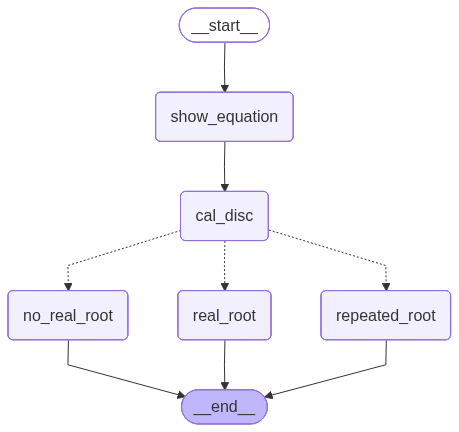

In [14]:
# Visualize the graph 
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [16]:
# Execute Graph
initial_state = {
    'a': 6,
    'b': -5,
    'c': 2
}
workflow.invoke(initial_state)

{'a': 6,
 'b': -5,
 'c': 2,
 'equation': '6x2+-5x+2',
 'discriminant': -23,
 'result': 'No real Roots'}